# End-to-End Peak Detection & Pseudo-Voigt Refinement Pipeline

This notebook demonstrates the complete physics-informed pipeline on a single experimental Raman spectrum (`data/experiment_1/VV.txt`).

### Pipeline Stages:
1. **Data Ingestion & Resampling**: Loads experimental spectrum and interpolates onto model frequency mesh $W$.
2. **FCN Dense Detection**: Predicts peak locations, heights, and linewidth proxies.
3. **False-Positive Noise Filtering**: Checks raw signal support to reject spurious noise activations.
4. **Proxy Reconstruction**: Visualizes initial synthetic curve directly from FCN parameters.
5. **Global Non-Linear Refinement**: Warm-starts `scipy.optimize.least_squares` with Pseudo-Voigt profiles across all peaks.
6. **Divide-and-Conquer Regional Refinement**: Partitions spectrum into natural "islands" for fast, robust multi-peak fitting without cross-region parameter interference.

In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Add project root to sys.path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

from src.lineshapes import pseudo_voigt
from src.signal_sample_module import convert_peaks_to_signal
from src.inference import load_model, predict_peaks_dense, resample_to_training_grid
from processing.peak_filters_by_raw_signal import filter_by_raw_signal_flat, filter_by_raw_signal
from processing.refinement_fit import refine, refine_grouped, estimate_global_baseline
from processing.plotting import plot_reconstruction

# Set styling and random seed
torch.manual_seed(0)
rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

# Hardware device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Load Model & Configurations

In [3]:
model_path = '../saved_models/dense_model.pt'
config_path = '../saved_models/dense_model_config.json'

cnn_model, cfg, device = load_model(model_path, config_path, device=device, mode="eval")
W = cfg.W  # Model training frequency mesh

print(f"Loaded DenseDetector model. Frequency mesh spans {cfg.pos_range[0]} to {cfg.pos_range[1]} cm^-1 ({len(W)} points).")

FCN layer spec
{'out_channels': 16, 'kernel_size': 9, 'stride': 1}
{'out_channels': 32, 'kernel_size': 7, 'stride': 2}
{'out_channels': 64, 'kernel_size': 5, 'stride': 2}
{'out_channels': 128, 'kernel_size': 3, 'stride': 2}
Loaded DenseDetector model. Frequency mesh spans 0 to 800.0 cm^-1 (4000 points).


## 2. Load Experimental Raman Spectrum
Loads raw experimental data ($I_{\text{VV}}$ polarization) and displays raw measurement points.

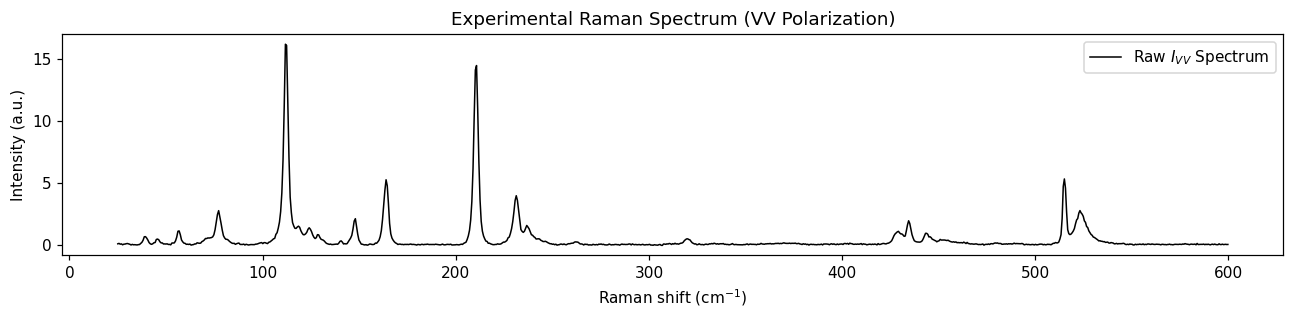

In [4]:
data_path = '../data/experiment_1/VV.txt'
data = np.loadtxt(data_path, skiprows=1)

real_freq = data[:, 0]
real_intensity = data[:, 1]

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(real_freq, real_intensity, color="black", lw=1.0, label="Raw $I_{VV}$ Spectrum")
ax.set_xlabel("Raman shift (cm$^{-1}$)")
ax.set_ylabel("Intensity (a.u.)")
ax.set_title("Experimental Raman Spectrum (VV Polarization)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 3. FCN Peak Detection & False-Positive Signal Filtering
1. Resamples the raw spectrum onto the training grid $W$.
2. Performs forward inference with `DenseDetector` to locate candidate peaks.
3. Applies raw-signal thresholding (`filter_by_raw_signal_flat`) to reject spurious noise triggers.

FCN raw candidate detections: 67
Detections confirmed after raw signal filtering: 37


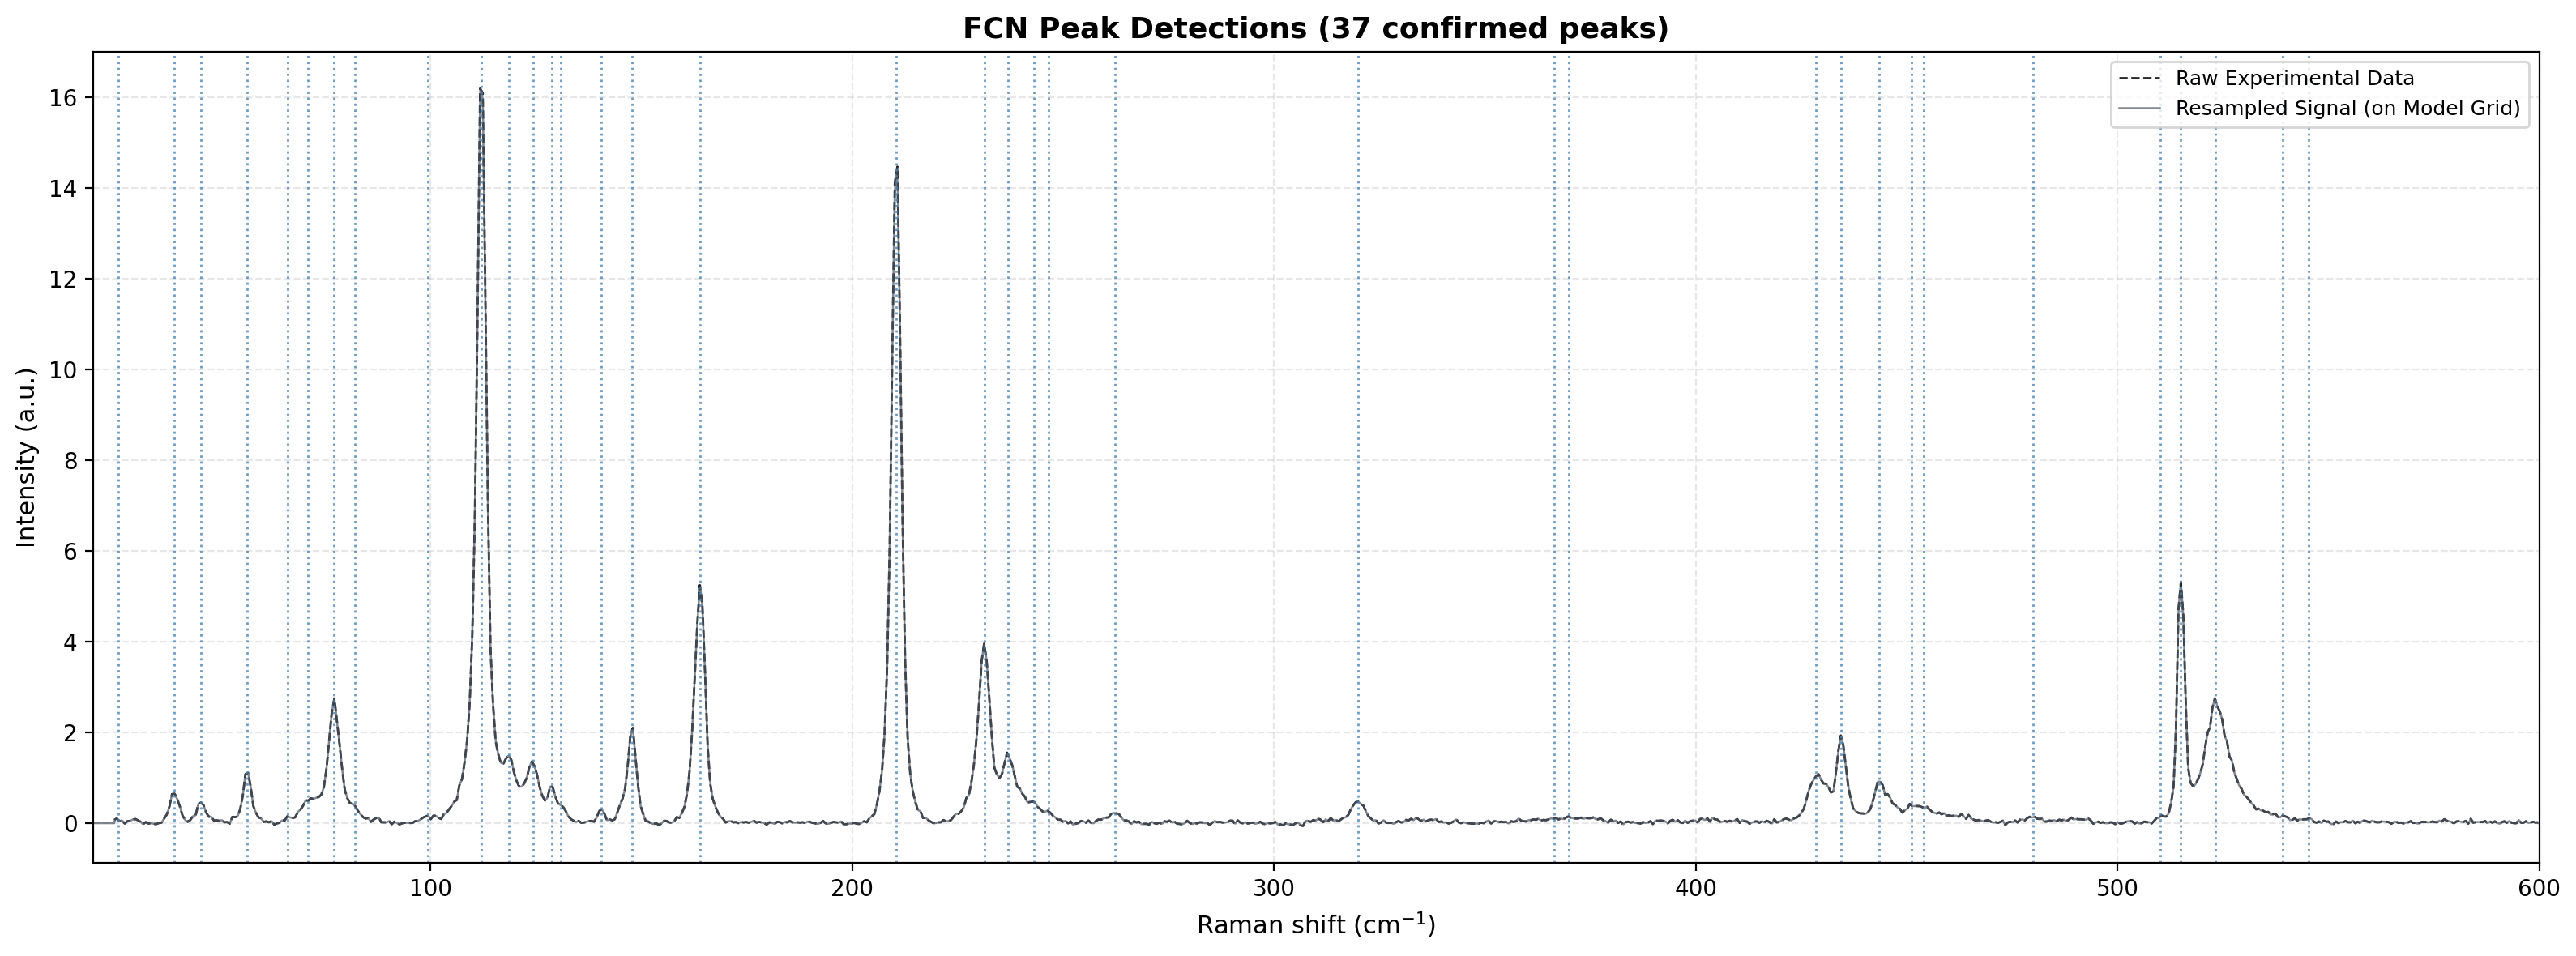

In [ ]:
# Resample onto cfg.W (required to align with FCN convolutional receptive field)
raw_resampled = resample_to_training_grid(real_freq, real_intensity, cfg.W)

# Light smoothing for noise suppression before resampling, for detection not for fitting
smooth_intensity = savgol_filter(raw_resampled, window_length=3, polyorder=1)

# FCN inference: outputs (confidence, amplitude, position, gamma)
detected = predict_peaks_dense(cnn_model, smooth_intensity, threshold=0.5, cfg=cfg, device=device)
print(f"FCN raw candidate detections: {len(detected)}")

# Filter candidate peaks by checking local raw signal intensity
signal_threshold = 0.10
peaks_filtered = filter_by_raw_signal_flat(detected, cfg.W, raw_resampled, cfg, threshold=signal_threshold)
print(f"Detections confirmed after raw signal filtering: {len(peaks_filtered)}")

# Visualize detected peaks overlaid on spectrum using unified plot_reconstruction
fig = plot_reconstruction(
    freq=W,
    raw_signal=raw_resampled,
    fit_result=None,
    predicted_peaks=peaks_filtered,
    raw_freq=real_freq,
    raw_intensity=real_intensity,
    show_predicted_lines=True,
    title=f"FCN Peak Detections ({len(peaks_filtered)} confirmed peaks)",
    xlim=(20, 600),
    show_plot=True
)

## 4. Initial Reconstruction Directly from FCN Parameters
Reconstructs synthetic lineshapes using the FCN's direct predictions as a baseline check prior to non-linear curve fitting.

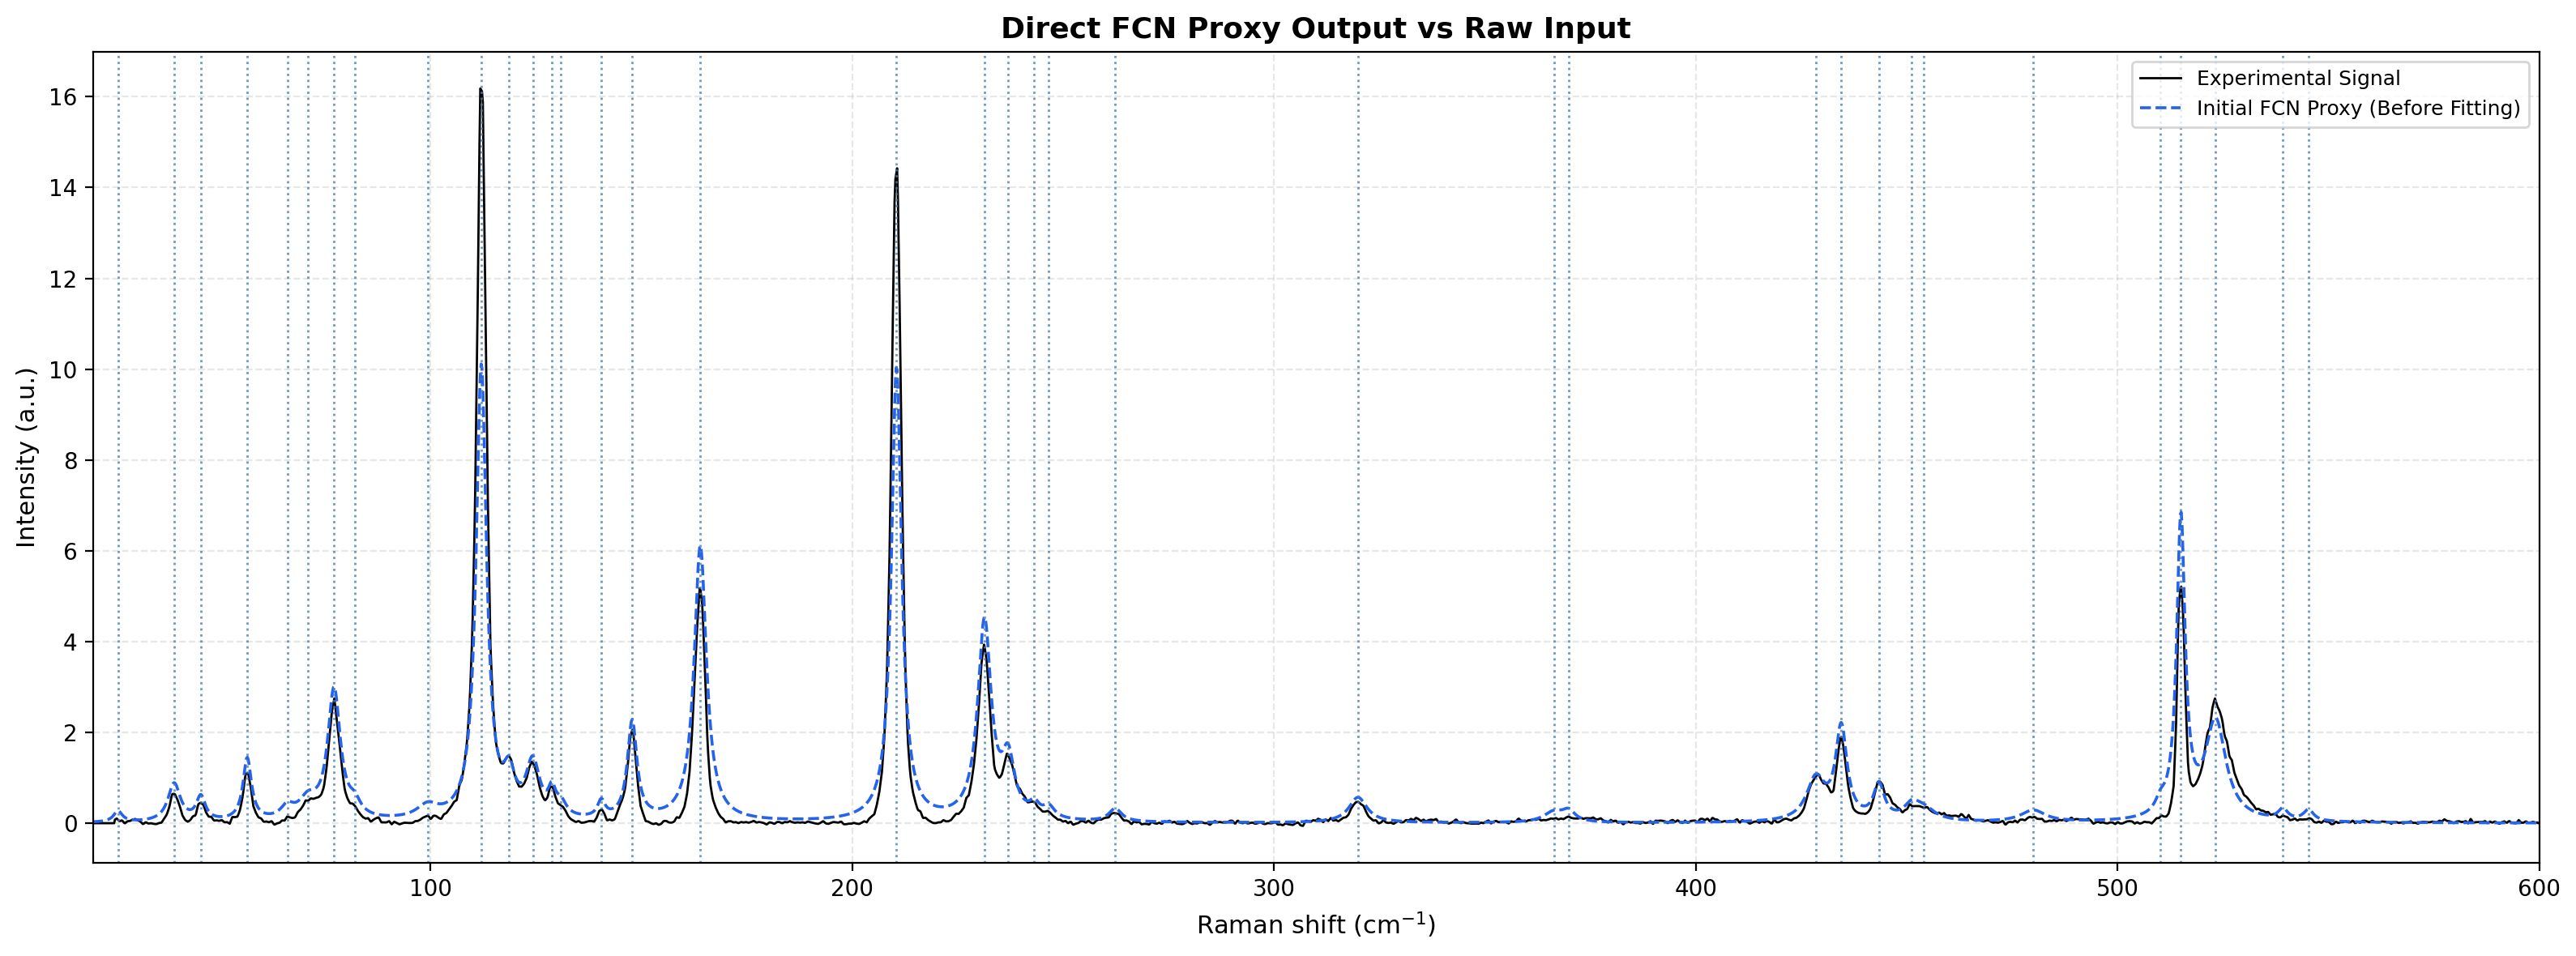

In [6]:
# Direct FCN proxy output vs raw input using unified plot_reconstruction
fig = plot_reconstruction(
    freq=W,
    raw_signal=raw_resampled,
    fit_result=None,
    predicted_peaks=peaks_filtered,
    show_initial_proxy=True,
    show_predicted_lines=True,
    title="Direct FCN Proxy Output vs Raw Input",
    xlim=(20, 600),
    show_plot=True
)

## 5. Non-Linear Least Squares Refinement (Pseudo-Voigt)

The FCN provides accurate peak localization, but its amplitude and width outputs are Lorentzian proxies. 
In the refinement stage:
- We swap to **Pseudo-Voigt** lineshapes: $I(x) = \eta L(x) + (1-\eta) G(x)$ with mixing parameter $\eta \in [0, 1]$ and width $\sigma \approx 2\gamma$.
- We warm-start `scipy.optimize.least_squares` with bounds centered at the FCN predictions.
- We use a robust loss (`soft_l1`) to prevent residual outliers from pulling adjacent peaks.

In [7]:
# Isolate active spectral region (where signal is non-zero)
nonzero_idx = np.flatnonzero(raw_resampled)
f_begin, f_end = nonzero_idx[0], nonzero_idx[-1]

freq_in = W[f_begin:f_end]
raw_signal_in = raw_resampled[f_begin:f_end]

print(f"Active fitting window: {freq_in[0]:.1f} cm^-1 to {freq_in[-1]:.1f} cm^-1 ({len(freq_in)} points)")

Active fitting window: 25.2 cm^-1 to 599.3 cm^-1 (2871 points)


### 5.1. Global Bounded Refinement (All Peaks Simultaneous)

Fitting all peaks simultaneously...
`xtol` termination condition is satisfied.
Function evaluations 14, initial cost 1.4549e+02, final cost 3.3708e+00, first-order optimality 3.64e-01.
Fit success: True, Cost: 3.3708
Fitted Baseline: b0 = -7.8261e-02, b1 = 1.6237e-04


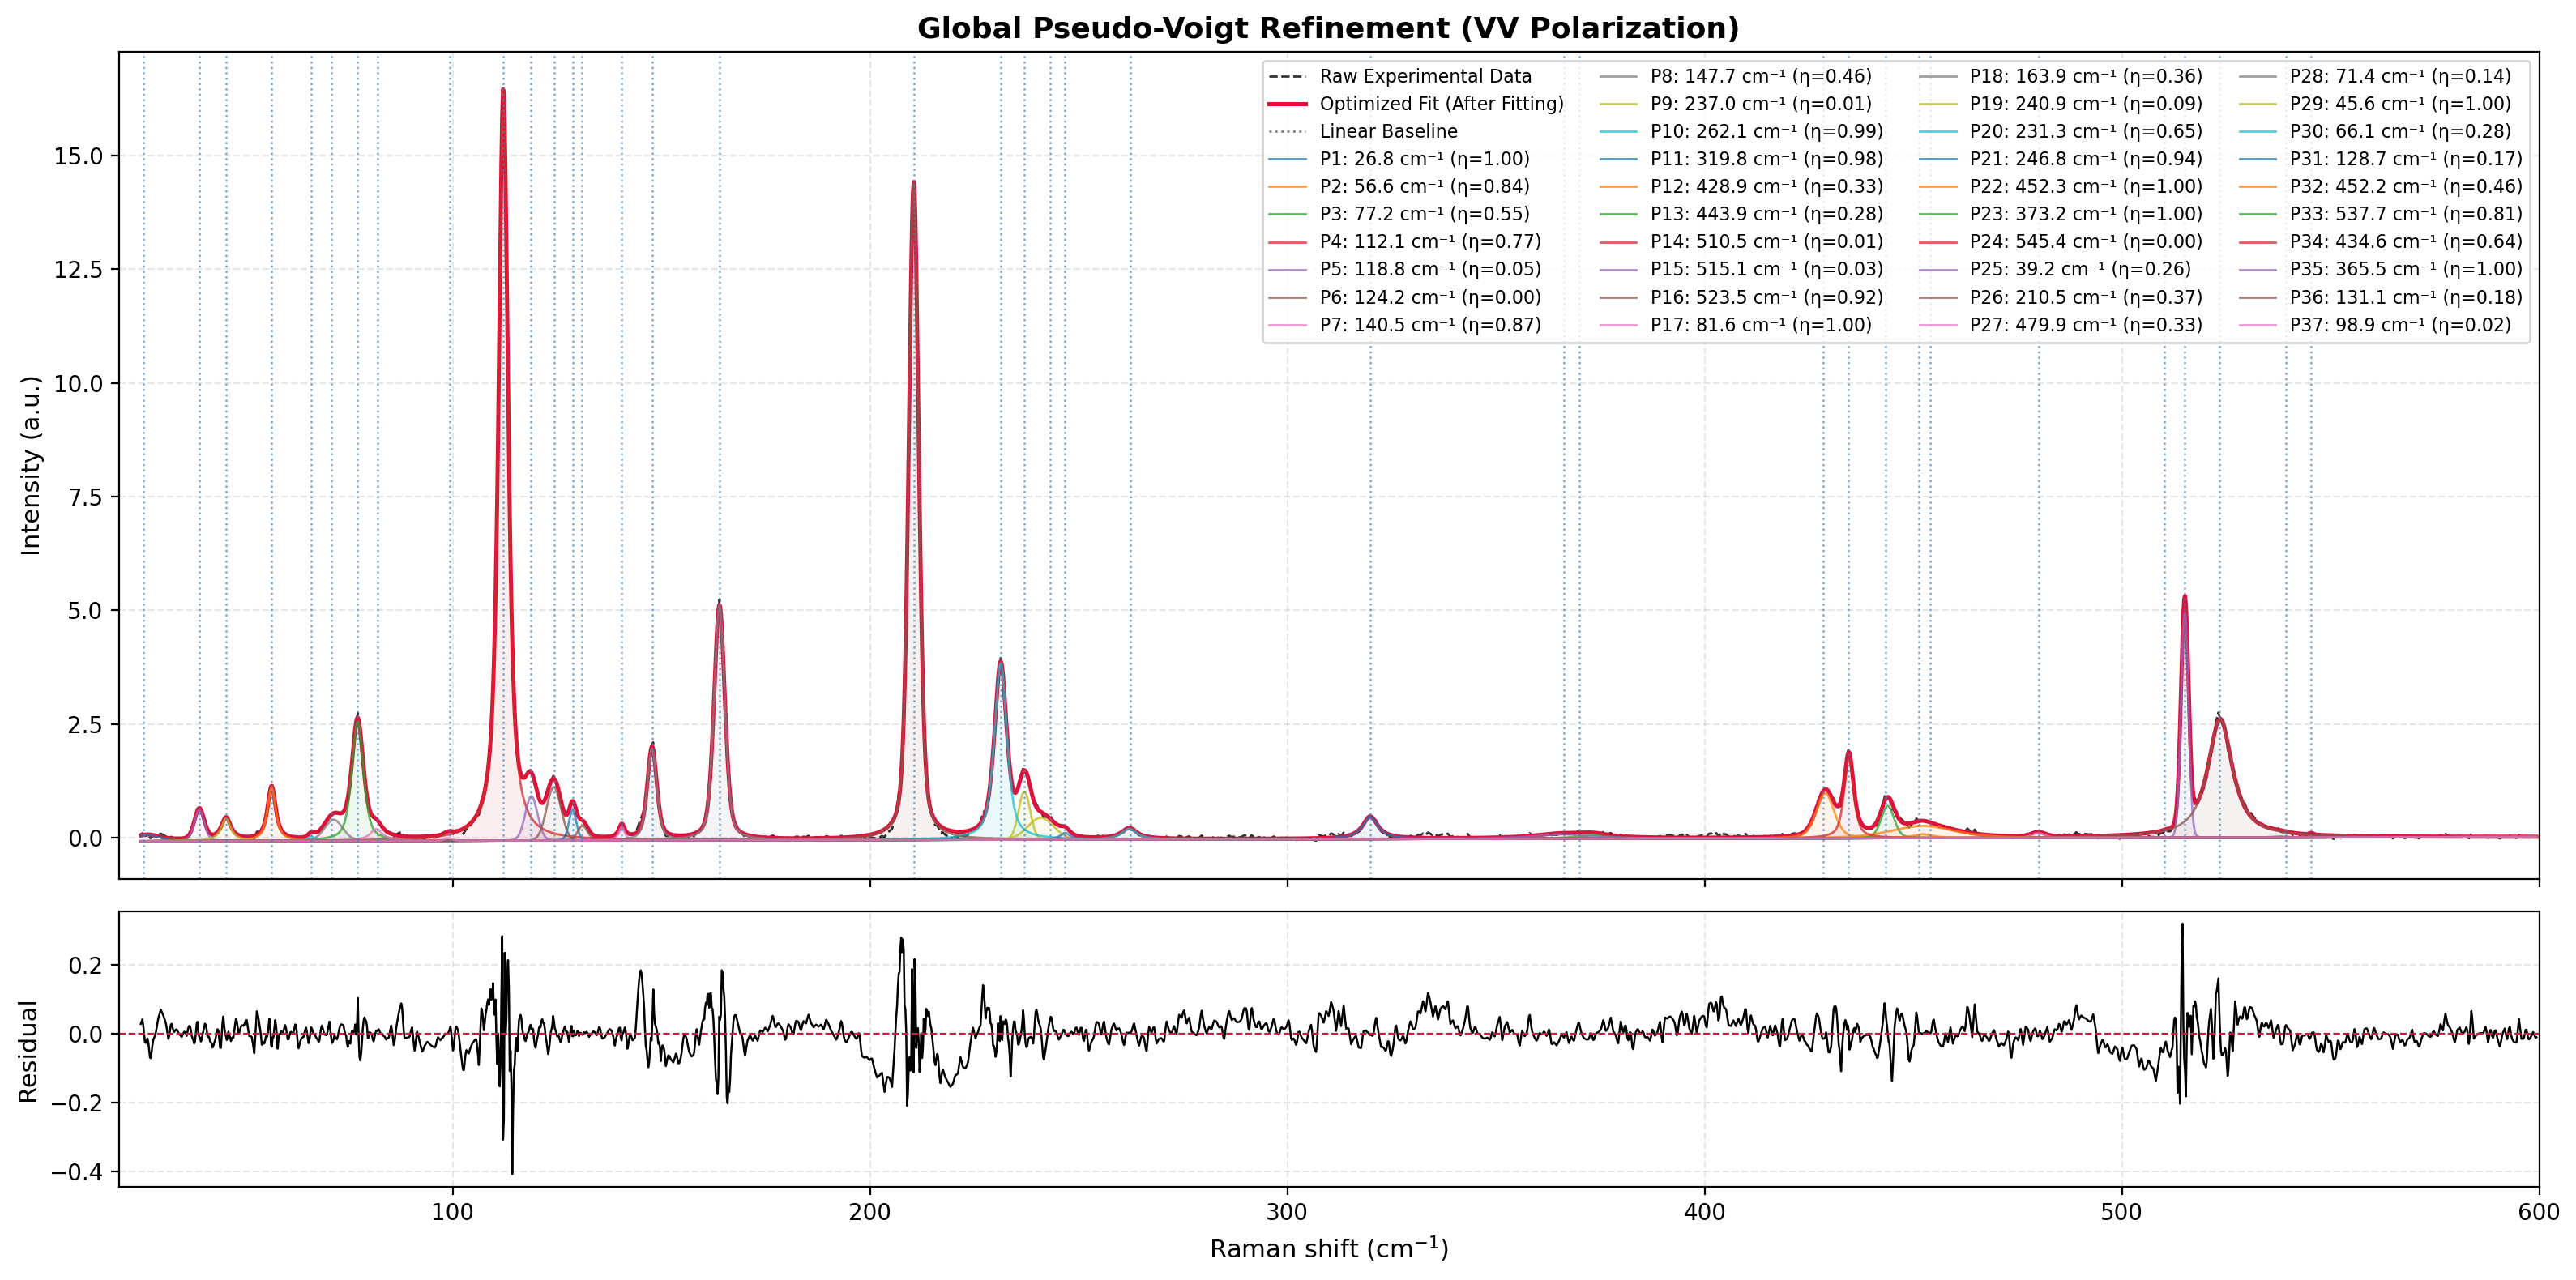

In [8]:
# Execute global non-linear least squares fit
print("Fitting all peaks simultaneously...")
out_global = refine(freq_in, raw_signal_in, peaks_filtered, pos_window=5.0, width_scale=3.0, loss="soft_l1", verbose=1)

print(f"Fit success: {out_global['success']}, Cost: {out_global['cost']:.4f}")
print(f"Fitted Baseline: b0 = {out_global['baseline'][0]:.4e}, b1 = {out_global['baseline'][1]:.4e}")

# Plot reconstructed fit, decomposed pseudo-Voigt components, and residual
fig = plot_reconstruction(
    freq=freq_in,
    raw_signal=raw_signal_in,
    fit_result=out_global,
    predicted_peaks=peaks_filtered,
    raw_freq=real_freq,
    raw_intensity=real_intensity,
    show_optimized_fit=True,
    show_components=True,
    title="Global Pseudo-Voigt Refinement (VV Polarization)",
    xlim=(20, 600),
    show_plot=True
)

### 5.2. Divide-and-Conquer Regional Refinement
For spectra with many overlapping peaks, fitting the entire spectrum at once can be computationally stiff. 
`refine_grouped` partitions the spectrum into natural "islands" based on linewidth-aware separation thresholds and fits each region independently after subtracting a shared global baseline.

Partitioned into 16 regional peak groups.
Total refined peaks: 37


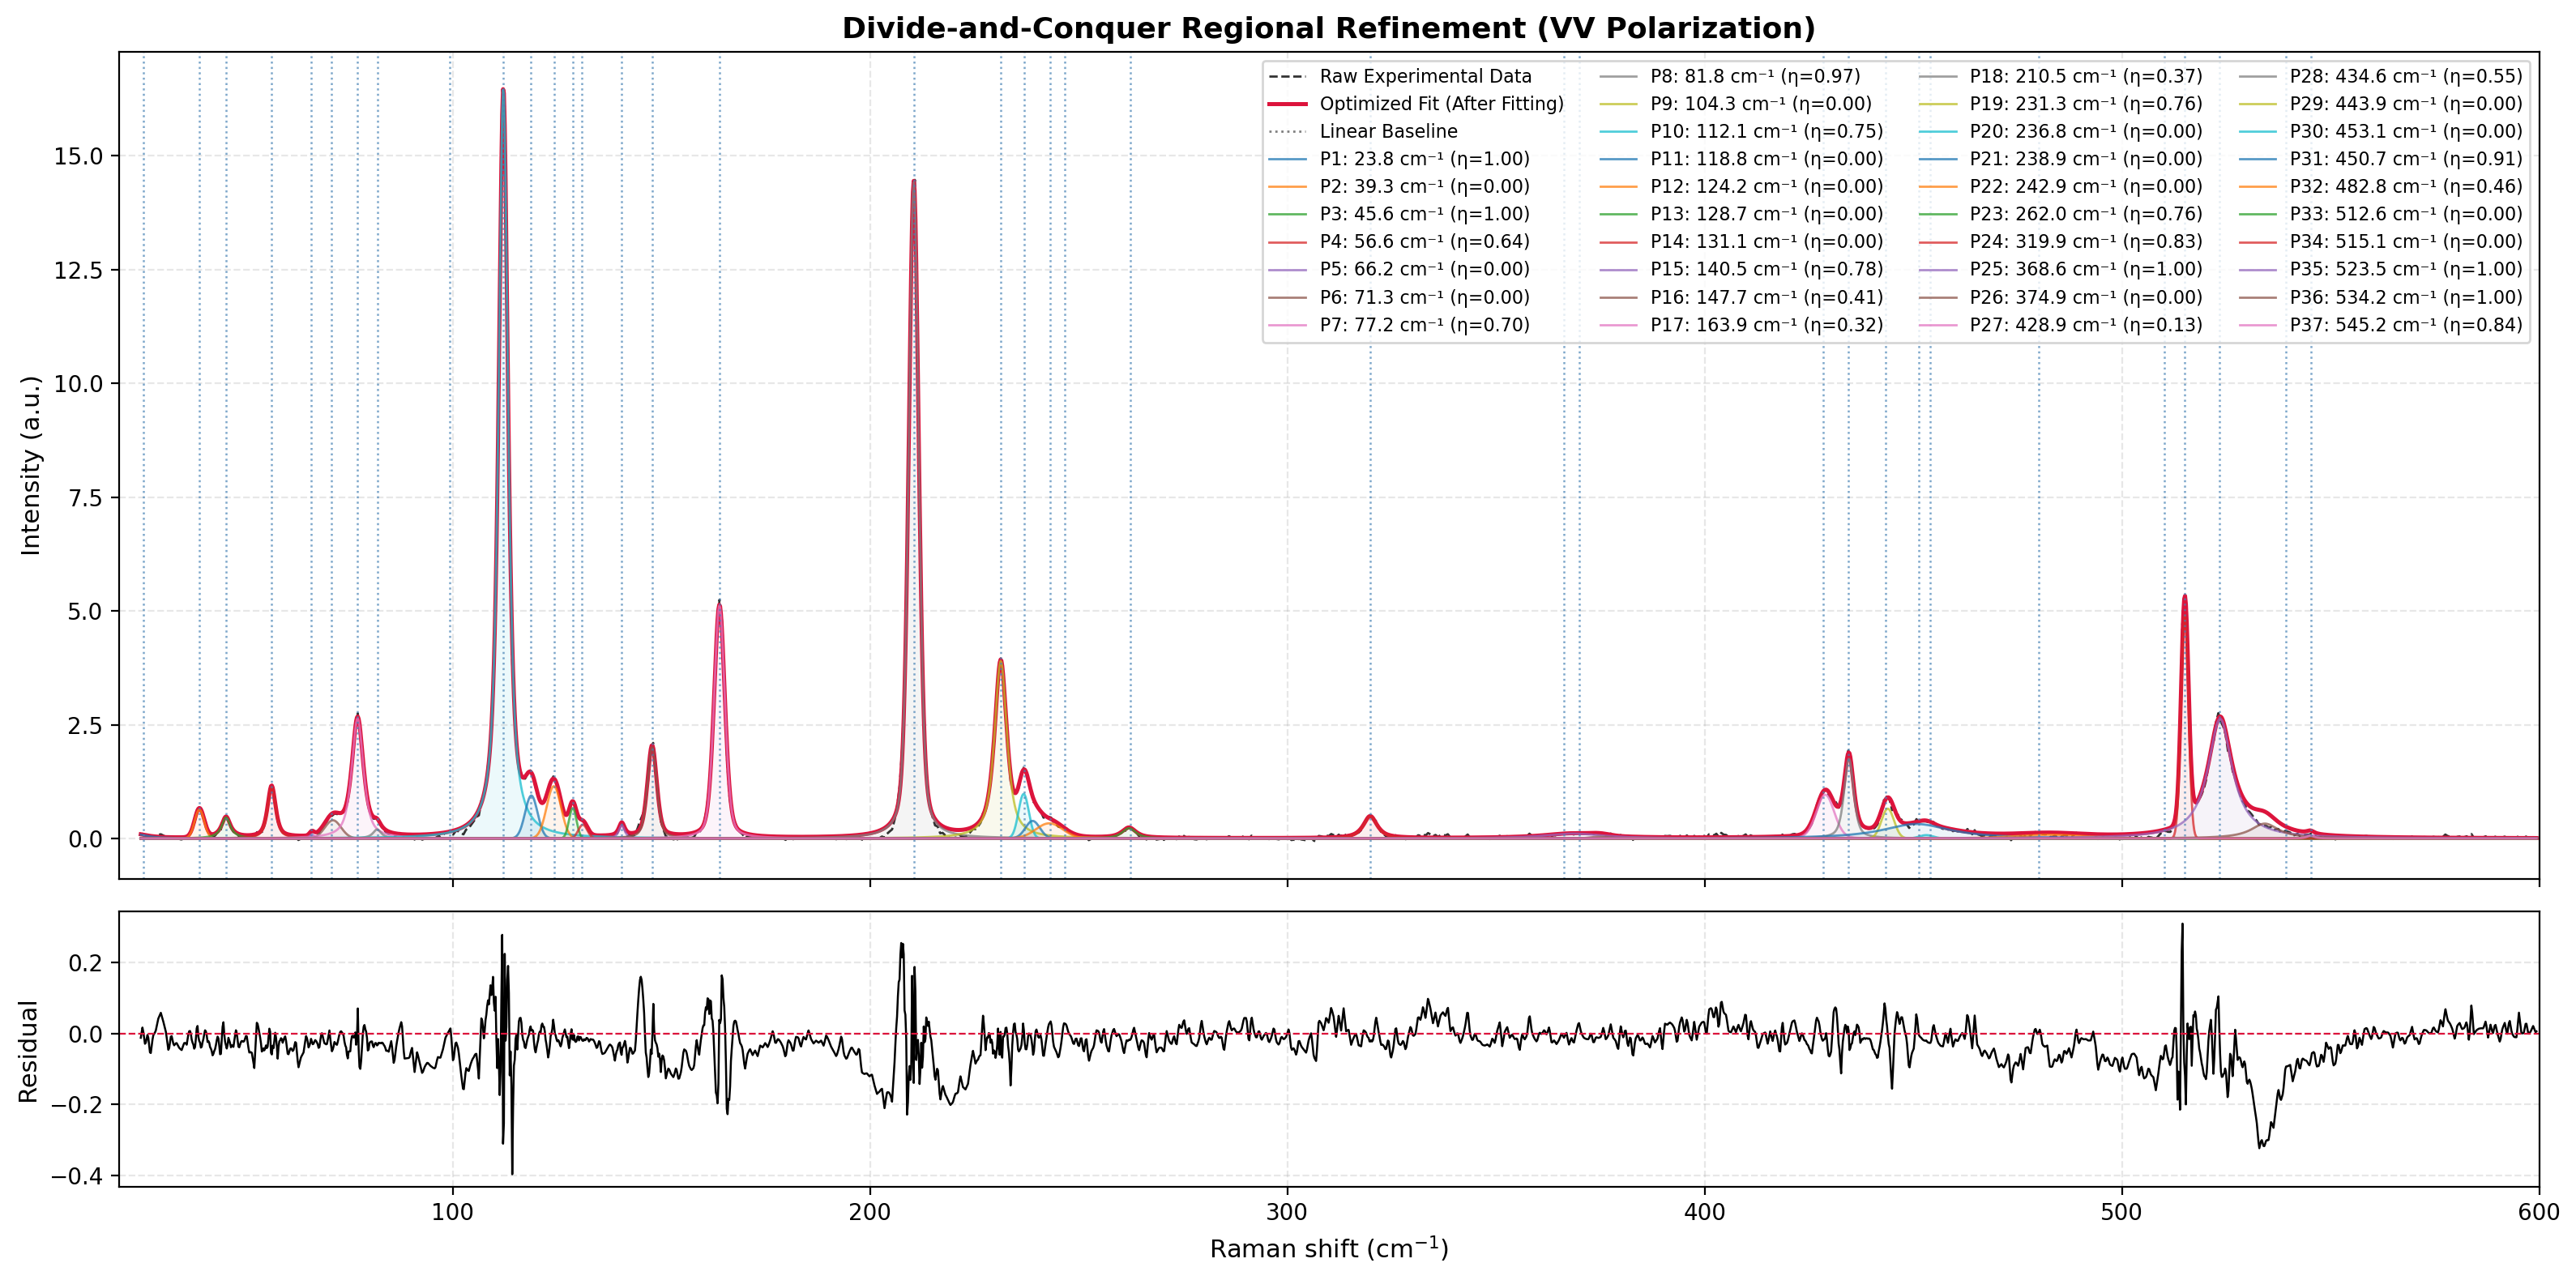

In [9]:
# Execute grouped / regional non-linear refinement
out_grp = refine_grouped(
    freq_in, raw_signal_in, peaks_filtered,
    target_peaks_per_group=5,
    separation_factor=3.0,
    low_signal_threshold=0.10,
    pad=15.0,
    verbose=0
)

print(f"Partitioned into {len(out_grp['groups'])} regional peak groups.")
print(f"Total refined peaks: {len(out_grp['peaks'])}")

# Plot reconstructed fit with regional pseudo-Voigt components and residuals
fig_grp = plot_reconstruction(
    freq=freq_in,
    raw_signal=raw_signal_in,
    fit_result=out_grp,
    predicted_peaks=peaks_filtered,
    raw_freq=real_freq,
    raw_intensity=real_intensity,
    show_optimized_fit=True,
    show_components=True,
    title="Divide-and-Conquer Regional Refinement (VV Polarization)",
    xlim=(20, 600),
    save_path="reconstruction_demo.png",
    show_plot=True
)